# 09 · 하중조합 — KDS 14 20 10 4.2.2

강도설계법의 하중계수 조합 식 (4.2-1) ~ 식 (4.2-8) 을 평가한다.

| 식 | 조합 |
|---|---|
| (4.2-1) | $U = 1.4(D+F)$ |
| (4.2-2) | $U = 1.2(D{+}F{+}T) + 1.6(L + \alpha_H H_v + H_h) + 0.5(L_r/S/R)$ |
| (4.2-3) | $U = 1.2D + 1.6(L_r/S/R) + (1.0L$ 또는 $0.65W)$ |
| (4.2-4) | $U = 1.2D + 1.3W + 1.0L + 0.5(L_r/S/R)$ |
| (4.2-5) | $U = 1.2(D{+}H_v) + 1.0E + 1.0L + 0.2S + (1.0H_h$ 또는 $0.5H_h)$ |
| (4.2-6) | $U = 1.2(D{+}F{+}T) + 1.6(L + \alpha_H H_v) + 0.8H_h + 0.5(L_r/S/R)$ |
| (4.2-7) | $U = 0.9(D{+}H_v) + 1.3W + (1.6H_h$ 또는 $0.8H_h)$ |
| (4.2-8) | $U = 0.9(D{+}H_v) + 1.0E + (1.0H_h$ 또는 $0.5H_h)$ |

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
from concreteproperties_kds.loads import (
    LOAD_SYMBOLS,
    alpha_h,
    evaluate_all,
    minimum_strength,
    print_combinations,
    required_strength,
)

# 8 m 경간 보의 단위길이당 하중 (kN/m)
loads = {
    "D": 25.0, "L": 18.0, "L_r": 3.0,
    "S": 5.0, "W": 12.0, "E": 20.0,
}

for symbol, value in loads.items():
    print(f"  {symbol:>4} ({LOAD_SYMBOLS[symbol]}) = {value:7.2f} kN/m")

     D (고정하중) =   25.00 kN/m
     L (활하중) =   18.00 kN/m
   L_r (지붕활하중) =    3.00 kN/m
     S (적설하중) =    5.00 kN/m
     W (풍하중) =   12.00 kN/m
     E (지진하중) =   20.00 kN/m


In [3]:
print_combinations(loads=loads)

하중조합 (KDS 14 20 10 4.2.2)
     조합        식            U                                                            
------------------------------------------------------------------------------------------------
   U5-a    4.2-5        69.00  U = 1.2(D+H_v) + 1.0E + 1.0L + 0.2S + 1.0H_h               <= 지배
   U5-b    4.2-5        69.00  U = 1.2(D+H_v) + 1.0E + 1.0L + 0.2S + 0.5H_h              
     U4    4.2-4        66.10  U = 1.2D + 1.3W + 1.0L + 0.5(L_r or S or R)               
     U2    4.2-2        61.30  U = 1.2(D+F+T) + 1.6(L + aH*H_v + H_h) + 0.5(L_r or S or R)
     U6    4.2-6        61.30  U = 1.2(D+F+T) + 1.6(L + aH*H_v) + 0.8H_h + 0.5(L_r or S or R)
   U3-L    4.2-3        56.00  U = 1.2D + 1.6(L_r or S or R) + 1.0L                      
   U3-W    4.2-3        45.80  U = 1.2D + 1.6(L_r or S or R) + 0.65W                     
   U8-a    4.2-8        42.50  U = 0.9(D + H_v) + 1.0E + 1.0H_h                          
   U8-b    4.2-8        42.50  U = 0.9(D + H_v) + 1.0E +

In [4]:
u_max, governing = required_strength(loads=loads)
span = 8.0

print(f"소요강도 wu = {u_max:.2f} kN/m  "
      f"({governing.name}, 식 {governing.equation})")
print(f"계수 휨모멘트 Mu = wu*l^2/8 = {u_max * span ** 2 / 8:.2f} kN.m")
print(f"계수 전단력   Vu = wu*l/2   = {u_max * span / 2:.2f} kN")

소요강도 wu = 69.00 kN/m  (U5-a, 식 4.2-5)
계수 휨모멘트 Mu = wu*l^2/8 = 552.00 kN.m
계수 전단력   Vu = wu*l/2   = 276.00 kN


## 연직토압 보정계수 (KDS 14 20 10 4.2.2(1))

$$\alpha_H = \begin{cases}
1.0 & h \le 2\ \text{m} \\
1.05 - 0.025h \ \ge 0.875 & h > 2\ \text{m}
\end{cases}$$

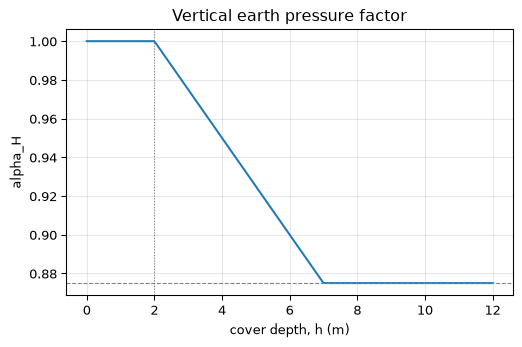

In [5]:
h = np.linspace(0, 12, 200)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(h, [alpha_h(depth=float(x)) for x in h])
ax.axhline(0.875, ls="--", color="grey", lw=0.8)
ax.axvline(2.0, ls=":", color="grey", lw=0.8)
ax.set_xlabel("cover depth, h (m)")
ax.set_ylabel("alpha_H")
ax.set_title("Vertical earth pressure factor")
ax.grid(alpha=0.3)
plt.show()

## 활하중 계수 저감 (KDS 14 20 10 4.2.2(2))

활하중이 5.0 kN/m² 미만이고 차고·공공집회 장소가 아니면 식 (4.2-3),
(4.2-4), (4.2-5) 의 활하중 계수를 1.0 에서 0.5 로 낮출 수 있다.

In [6]:
full = {c.name: v for c, v in evaluate_all(loads=loads)}
reduced = {
    c.name: v for c, v in evaluate_all(loads=loads, reduce_live_load=True)
}

for name in sorted(full):
    if abs(full[name] - reduced[name]) > 1e-9:
        print(f"  {name:>6} : {full[name]:8.2f} -> {reduced[name]:8.2f} kN/m")

    U3-L :    56.00 ->    47.00 kN/m
      U4 :    66.10 ->    57.10 kN/m
    U5-a :    69.00 ->    60.00 kN/m
    U5-b :    69.00 ->    60.00 kN/m


## 부양·전도 검토

풍하중이 부양으로 작용할 때는 고정하중 계수를 0.9 로 낮춘 식 (4.2-7),
(4.2-8) 이 지배한다.

In [7]:
uplift = {"D": 100.0, "W": -300.0}

u_min, governing_min = minimum_strength(loads=uplift)
print(f"최소 조합하중 = {u_min:.1f}  "
      f"({governing_min.name}, 식 {governing_min.equation})")
print(f"  {governing_min.description}")

최소 조합하중 = -300.0  (U7-b, 식 4.2-7)
  U = 0.9(D + H_v) + 1.3W + 0.8H_h
